In [1]:
from import_and_plotting_tech import *
import pickle

from ensemble_data import data_16_x_64_1p5Tc as data_ensemble
flowtimes = data_ensemble['flowtimes']

mats_list = [0, 1, 2]
iflows_mats = {
    0 : [11,12,14,16,18],
    1 : [11,12,14,16,18],
    2 : [11,12,14]
}
sub_list = [(0,1), (0,1,2)]

In [2]:
# load bootstrap ensemble
pickle_path = Path.cwd() / '..' / 'data' / 'bs_H.pkl'
with open(pickle_path, 'rb') as f:
    bs_data : list[ResultData] = pickle.load(f)
print('Number of bootstrap samples =', len(bs_data), end='\n\n\n')

# H_n and H_sub from bootstrap ensemble
H_ense = {}
for mats in mats_list:
    for iflow in iflows_mats[mats]:
        H_ense[f'H_{mats}_{iflow}'] = [rd.tsums_mats[iflow,mats] for rd in bs_data]
for sub in sub_list:
    for iflow in set.intersection(*(set(iflows_mats[mats]) for mats in sub)):
        H_ense[f'H_{sub}_{iflow}'] = [rd.tsums_subs[sub,iflow] for rd in bs_data]
H_data = gv.dataset.avg_data(H_ense, bstrap=True)

Number of bootstrap samples = 1000




In [20]:
# which data for fit
sub    = (0,1)
iflows = [11,18]

# x data (flowtimes)
x_data = flowtimes[iflows]
print(f'{x_data = !s}')

# y data (H_sub)
y_ense = np.zeros(shape=(len(bs_data),len(x_data)), dtype=float)
y_data = np.zeros(shape=(len(x_data),), dtype=object)
for iiflow, iflow in enumerate(iflows):
    y_ense[:,iiflow] = H_ense[f'H_{sub}_{iflow}']
    y_data[iiflow]   = H_data[f'H_{sub}_{iflow}']
print(f'{y_data = !s}')

print()
print(gv.evalcov(y_data))
print(gv.evalcorr(y_data))


x_data = [0.41794493 0.9353328 ]
y_data = [-0.0369(90) -0.0404(60)]

[[8.06427048e-05 5.10218309e-05]
 [5.10218309e-05 3.62604874e-05]]
[[1.         0.94353209]
 [0.94353209 1.        ]]


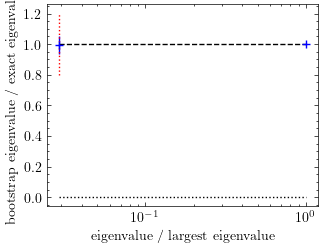

svd.eps=np.float64(0.02905426995758907), svd.nmod=0


In [4]:
# svd analysis
%matplotlib inline
svd = gv.dataset.svd_diagnosis(y_ense, nbstrap=500)
svd.plot_ratio(show=True)

print(f'{svd.eps=}, {svd.nmod=}')

fit result = -0.04377853426720842


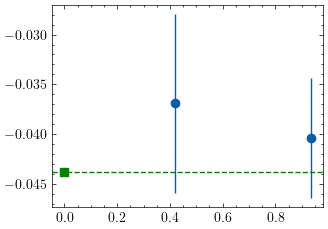

In [5]:
# linear fit
A    = np.ones(shape=(len(x_data),))
V    = gv.evalcov(y_data)
Vinv_A = np.linalg.solve(V, A)
L = Vinv_A.T / (A.T @ Vinv_A)

res = L @ gv.mean(y_data)
print('fit result =', res)

plt.errorbar(x_data, gv.mean(y_data), gv.sdev(y_data), linestyle='', marker='o')
plt.errorbar(0, res, marker='s', color='green')
plt.axhline(y=res, color='green', linestyle='--')
plt.show()

# Eigenvalues and eigenvectors of covariance matrix

In [6]:
eigvals, eigvecs = np.linalg.eig(gv.evalcov(y_data))
for i, ei in enumerate(eigvals):
    print(f'{ei:.8f}   {eigvecs[:,i]}')

0.00011409   [0.8363141 0.5482506]
0.00000281   [-0.5482506  0.8363141]


# Uncertainty and distribution of covariance

[[6.86(32)e-08 4.47(22)e-08]
 [4.47(22)e-08 3.26(16)e-08]]
[[1 ± 2.2e-16 0.9436(35)]
 [0.9436(35) 1 ± 2.2e-16]]


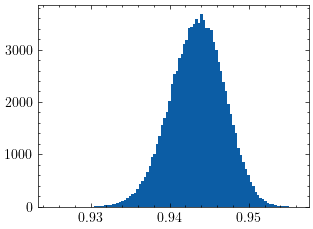

In [28]:
n_bs = 100000

y_cov_bs  = np.zeros(shape=(n_bs, len(y_data), len(y_data)), dtype=float)
y_corr_bs = np.zeros(shape=(n_bs, len(y_data), len(y_data)), dtype=float)

for i_bs, y_bs in enumerate(gv.dataset.bootstrap_iter(y_ense ,n=n_bs)):
    y_cov_bs[i_bs]  = gv.evalcov(gv.dataset.avg_data(y_bs))
    y_corr_bs[i_bs] = gv.evalcorr(gv.dataset.avg_data(y_bs))

y_cov = gv.dataset.avg_data(y_cov_bs, bstrap=True)
print(y_cov)

y_corr = gv.dataset.avg_data(y_corr_bs, bstrap=True)
print(y_corr)

plt.hist(y_corr_bs[:,1,0], bins=100)
plt.show()